# 01 - Бенчмарк: rolling-корреляция и DCC-GARCH (Фаза 1)

**Зачем эта фаза.** Прежде чем доставать вейвлеты, фиксируем, что говорит
*классический* инструментарий. Rolling-корреляция (и её «честный» эконометрический
апгрейд - DCC-GARCH) показывает, **что** связанность растёт в кризисы. Но обе
техники сворачивают все горизонты инвестирования в одно число на день.

**Ограничение классики, которое мотивирует вейвлеты:** rolling-корреляция отвечает
на вопрос «*что* связанность выросла», но не «*на каком горизонте*». Вейвлет-когерентность
(Фаза 2) отвечает на второй вопрос.

Данные: реальные дневные ряды TradingView (Binance/Kraken/индексы), Фаза 0.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src import benchmark as B

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True

returns = pd.read_parquet(C.PROCESSED_RETURNS)
print("returns:", returns.shape, "|", returns.index.min().date(), "..", returns.index.max().date())

returns: (1895, 11) | 2019-01-03 .. 2026-06-08


## 1. Rolling-корреляция: ключевые пары

Окна 30/90/250 дней. Красные полосы - стресс-эпизоды (COVID, Terra, 3AC, FTX, USDC/SVB).

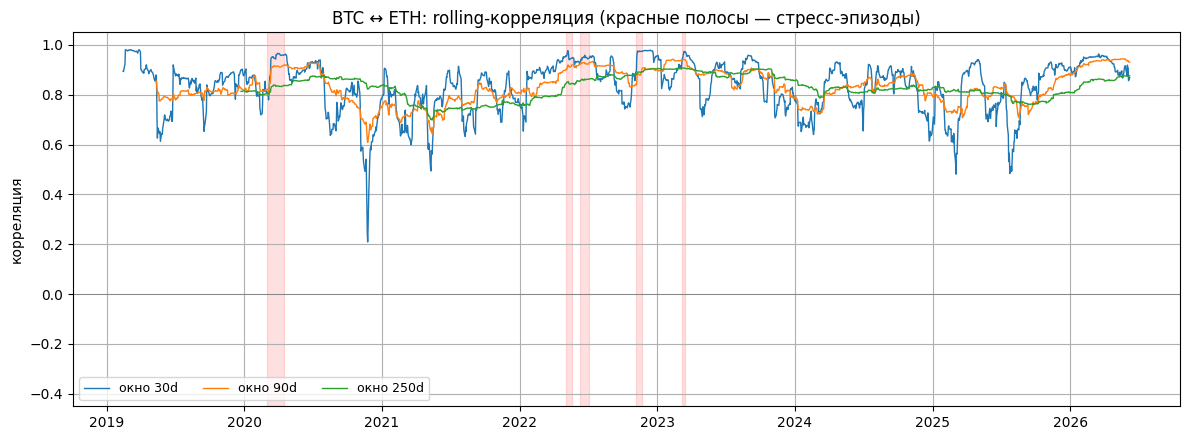

In [2]:
fig, ax = B.plot_benchmark_pair(returns, ("BTC", "ETH"))
plt.show()

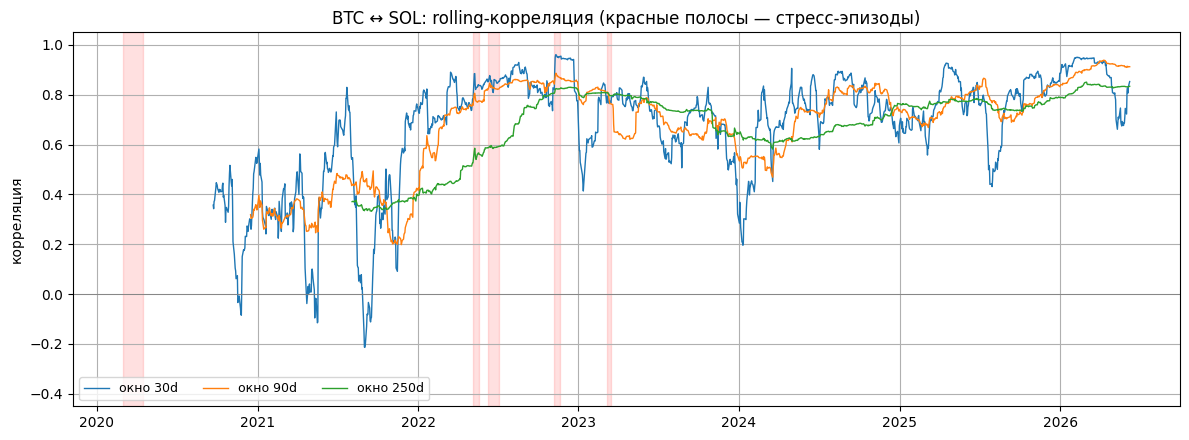

In [3]:
fig, ax = B.plot_benchmark_pair(returns, ("BTC", "SOL"))
plt.show()

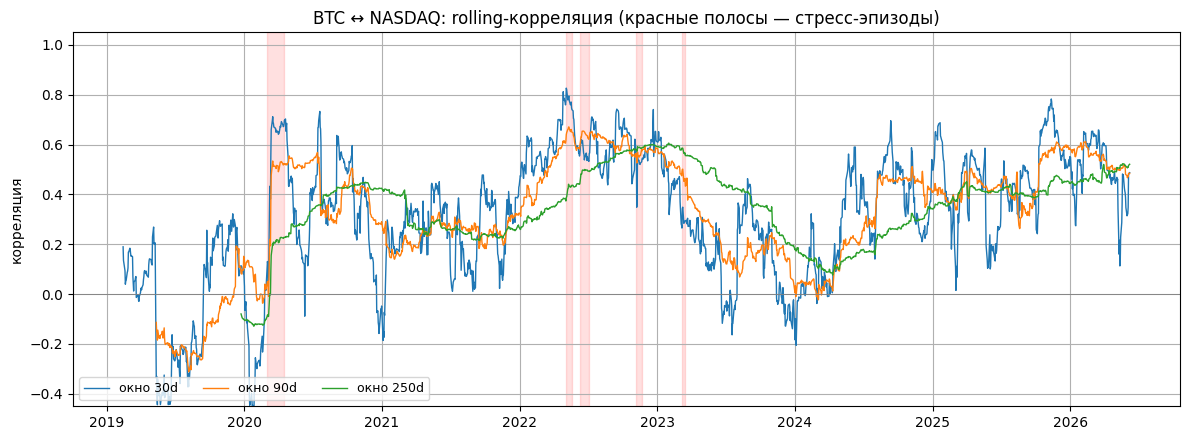

In [4]:
fig, ax = B.plot_benchmark_pair(returns, ("BTC", "NASDAQ"))
plt.show()

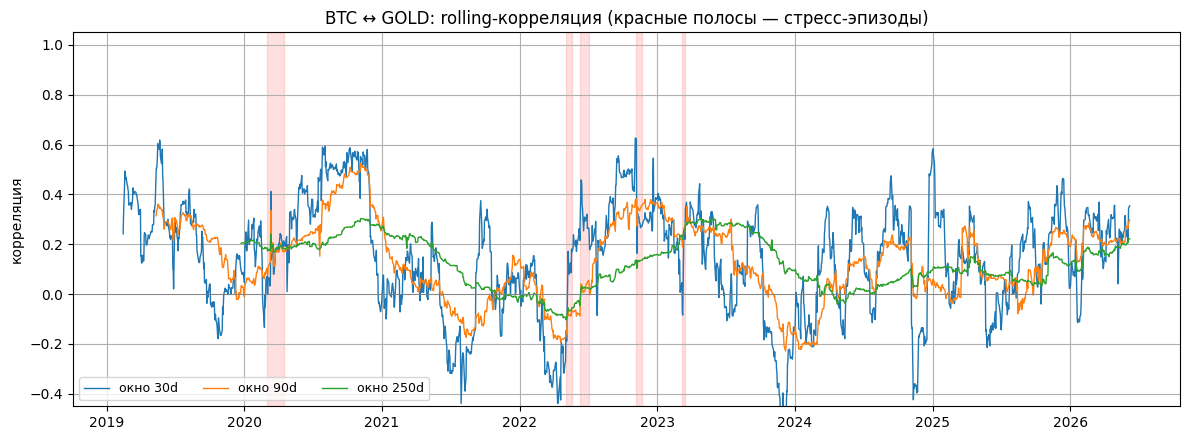

In [5]:
fig, ax = B.plot_benchmark_pair(returns, ("BTC", "GOLD"))
plt.show()

**Что видно уже на классике.**
- **BTC↔ETH**: корреляция почти всегда высокая - «диверсификация» внутри крипто-ядра
  иллюзорна даже в спокойные периоды.
- **BTC↔NASDAQ**: связь с риск-активами усиливается после 2020 и вспыхивает в стрессах -
  аргумент против «цифрового золота».
- **BTC↔GOLD**: корреляция нестабильна и в среднем низкая - золотом биткоин не работает.
- Короткое окно (30д) шумит, длинное (250д) запаздывает - классическая дилемма выбора
  окна, у вейвлетов её нет (разрешение адаптивно по частоте).

## 2. DCC-GARCH: эконометрически честная динамическая корреляция

Двухшаговый Engle (2002): GARCH(1,1) на каждом ряде → DCC(1,1) на стандартизованных остатках. В отличие от rolling-окна, DCC не требует выбора ширины окна и моделирует кластеризацию волатильности явно.

In [6]:
dcc_btc_eth, info1 = B.dcc_garch(returns, ("BTC", "ETH"))
print("BTC-ETH:", info1)
dcc_btc_ndx, info2 = B.dcc_garch(returns, ("BTC", "NASDAQ"))
print("BTC-NASDAQ:", info2)

BTC-ETH: {'a': 0.03694435753729146, 'b': 0.9554066175325477, 'loglik': -731.6013460547721, 'n_obs': 1895}


BTC-NASDAQ: {'a': 0.02111405574352271, 'b': 0.9710981609647681, 'loglik': -1767.0025390784635, 'n_obs': 1895}


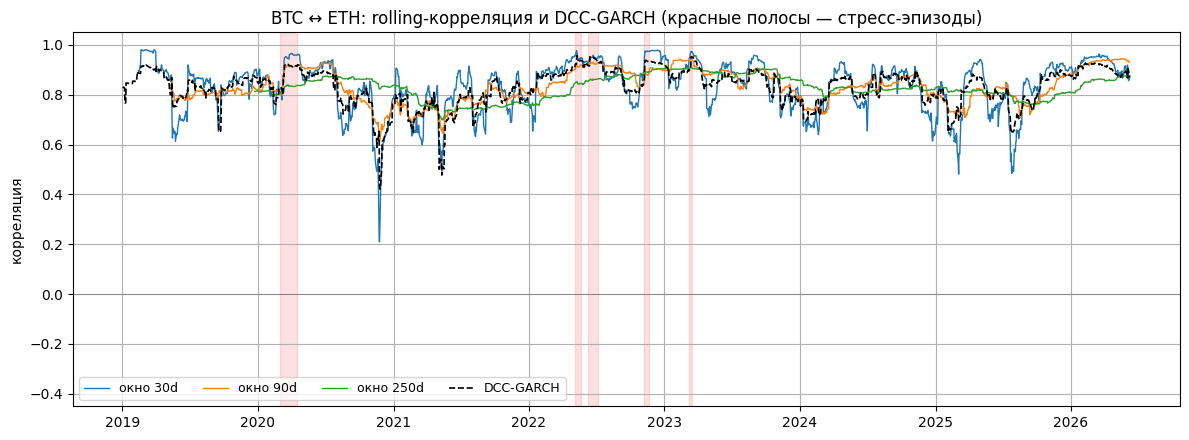

In [7]:
fig, ax = B.plot_benchmark_pair(returns, ("BTC", "ETH"), dcc=dcc_btc_eth)
plt.show()

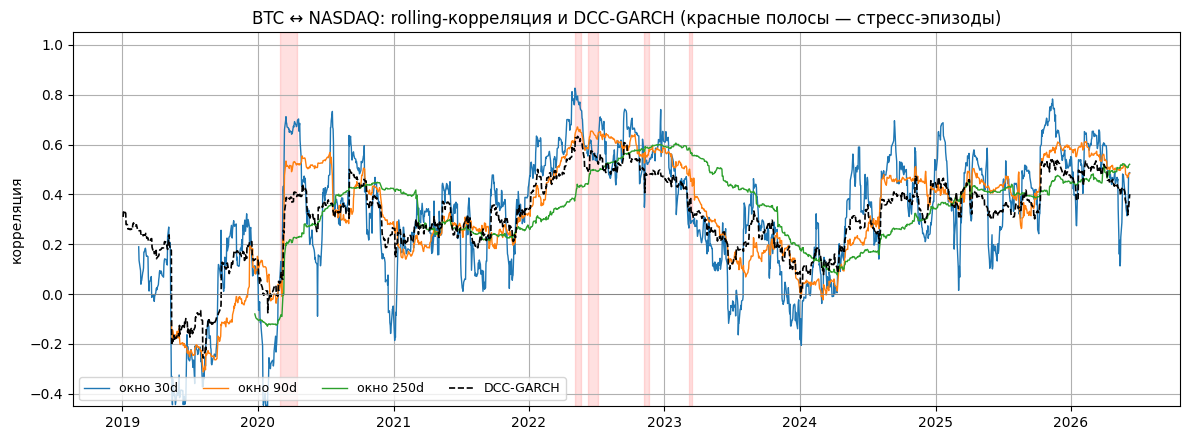

In [8]:
fig, ax = B.plot_benchmark_pair(returns, ("BTC", "NASDAQ"), dcc=dcc_btc_ndx)
plt.show()

## 3. Портфельный взгляд: средняя попарная корреляция

Одна линия на весь портфель: насколько «связана» книга сегодня. Прообраз раннего индикатора Фазы 4.

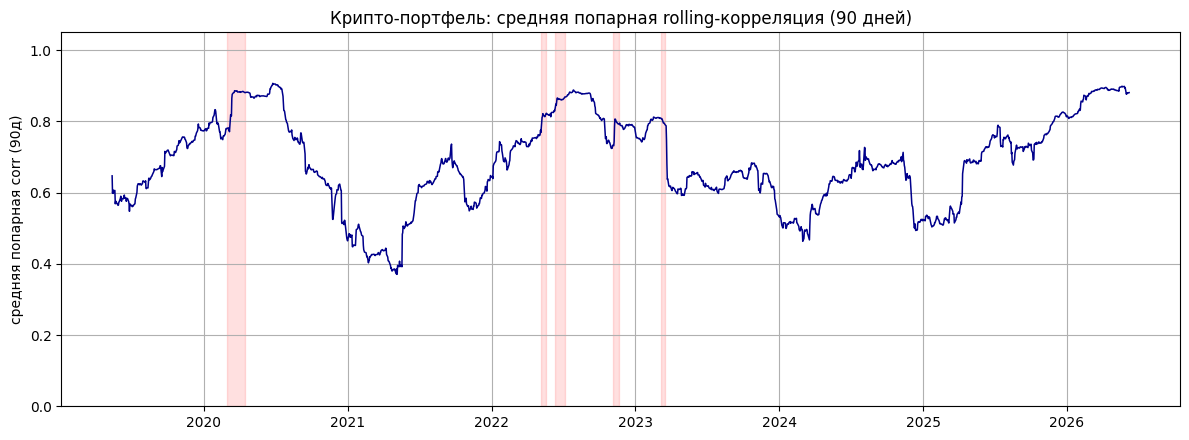

,эпизод,средняя corr
0,COVID crash,0.860
1,Terra/LUNA + UST de-peg,0.810
2,3AC / Celsius,0.859
3,FTX collapse,0.786
4,USDC de-peg / SVB,0.799
5,- вне эпизодов -,0.680


In [9]:
crypto = ["BTC", "ETH", "SOL", "BNB", "XRP"]
mpc = B.mean_pairwise_rolling_corr(returns, crypto, window=90)
fig, ax = plt.subplots()
ax.plot(mpc.index, mpc.values, lw=1.1, color="darkblue")
B.shade_episodes(ax)
ax.set_ylim(0, 1.05); ax.set_ylabel("средняя попарная corr (90д)")
ax.set_title("Крипто-портфель: средняя попарная rolling-корреляция (90 дней)")
fig.tight_layout(); fig.savefig(C.FIGURES / "01_mean_pairwise_corr.png", dpi=130)
plt.show()

# таблица: средняя корреляция в каждом эпизоде vs вне эпизодов
rows = []
stress_all = pd.Index([])
for ep in C.EPISODES:
    m = (mpc.index >= ep.start) & (mpc.index <= ep.end)
    stress_all = stress_all.union(mpc.index[m])
    rows.append({"эпизод": ep.name, "средняя corr": round(float(mpc[m].mean()), 3)})
rows.append({"эпизод": "- вне эпизодов -",
             "средняя corr": round(float(mpc.drop(index=stress_all).mean()), 3)})
summary = pd.DataFrame(rows)
summary.to_csv(C.RESULTS / "phase1_corr_by_episode.csv", index=False)
summary

## Вывод Фазы 1

1. Классика подтверждает базовый сюжет: **в каждом стресс-эпизоде связанность растёт**
   (rolling и DCC согласны), внутри крипты корреляция и так высока почти всегда.
2. Но и rolling, и DCC выдают **одно число на день** - усреднение по всем горизонтам.
   Какой горизонт несёт всплеск - дни (паника HFT/ритейла) или месяцы (режимный сдвиг) -
   классика ответить не может; окно 30д шумит, 250д запаздывает.
3. Этот вопрос - «**на каком горизонте ломается диверсификация?**» - и есть
   мотивация Фазы 2 (вейвлет-когерентность), где разрешение по времени и частоте
   адаптивно, а значимость проверяется Монте-Карло против AR(1)-суррогатов.